#### ***02 — Stationarity Analysis***

#### ***Imports***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

#### ***Load the processed series***

In [2]:
# Built in notebook 01
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

# Use only the training portion for stationarity diagnostics
TEST_DAYS = 30
split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train = data.loc[data.index < split_date].copy()

y = train['energy_kwh']
print(f'Training samples: {len(y)}')
print(f'Train range:      {y.index.min().date()} -> {y.index.max().date()}')

Training samples: 1897
Train range:      2018-08-22 -> 2023-10-31


#### ***Visualise the series***

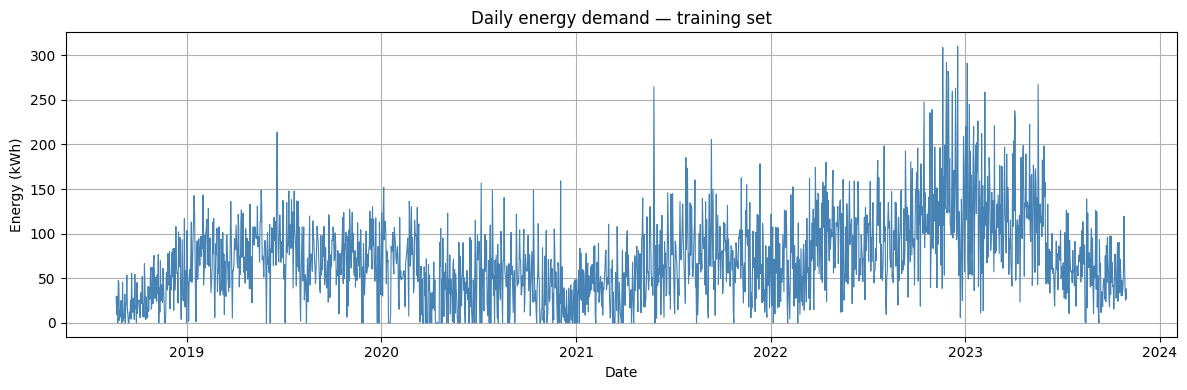

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y.index, y.values, color='steelblue', lw=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (kWh)')
ax.set_title('Daily energy demand — training set')
plt.tight_layout()
plt.show()

#### ***Rolling statistics***

We computed a 30-day rolling mean and standard deviation to get a first visual indication of trend and variance shifts.

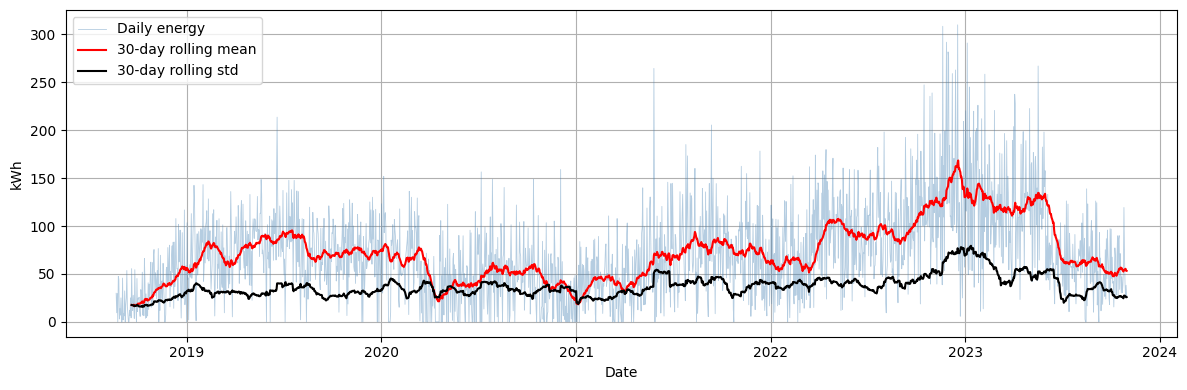

In [4]:
roll_mean = y.rolling(window=30).mean()
roll_std  = y.rolling(window=30).std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y,         color='steelblue', alpha=0.4, lw=0.6, label='Daily energy')
ax.plot(roll_mean, color='red',       lw=1.5,             label='30-day rolling mean')
ax.plot(roll_std,  color='black',     lw=1.5,             label='30-day rolling std')
ax.set_xlabel('Date'); ax.set_ylabel('kWh')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### ***Helper: ADF test***

We wrap `statsmodels.tsa.stattools.adfuller` to print the test statistic, p-value, and the conclusion at the 5 % significance level. *Null hypothesis: the series has a unit root (non-stationary).*

In [5]:
def adf_report(series, label=''):
    result = adfuller(series.dropna())
    stat, pvalue, _, _, crit, _ = result
    print(f'--- ADF test: {label} ---')
    print(f'ADF statistic : {stat:.4f}')
    print(f'p-value       : {pvalue:.6f}')
    for k, v in crit.items():
        print(f'  critical {k}: {v:.4f}')
    verdict = 'STATIONARY' if pvalue < 0.05 else 'NON-stationary'
    print(f'=> {verdict} at the 5% level\n')
    return pvalue

#### ***ADF on the raw series***

In [6]:
_ = adf_report(y, label='raw energy_kwh')

--- ADF test: raw energy_kwh ---
ADF statistic : -3.1597
p-value       : 0.022441
  critical 1%: -3.4338
  critical 5%: -2.8631
  critical 10%: -2.5676
=> STATIONARY at the 5% level



#### ***First differencing***

Removes any non-seasonal trend.

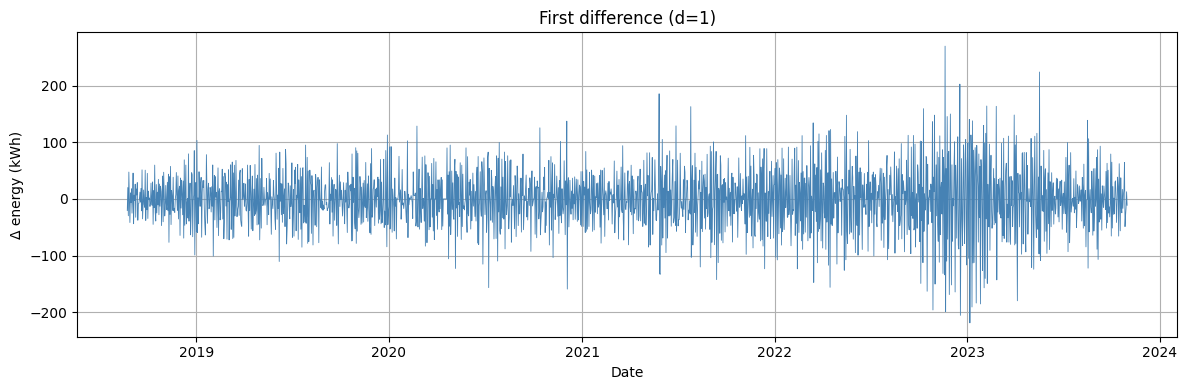

--- ADF test: first difference (d=1) ---
ADF statistic : -13.0561
p-value       : 0.000000
  critical 1%: -3.4339
  critical 5%: -2.8631
  critical 10%: -2.5676
=> STATIONARY at the 5% level



In [7]:
y_diff1 = y.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_diff1.index, y_diff1.values, color='steelblue', lw=0.6)
ax.set_title('First difference (d=1)')
ax.set_xlabel('Date'); ax.set_ylabel('Δ energy (kWh)')
plt.tight_layout()
plt.show()

_ = adf_report(y_diff1, label='first difference (d=1)')

#### ***Seasonal differencing (period = 7)***

Removes weekly seasonality.

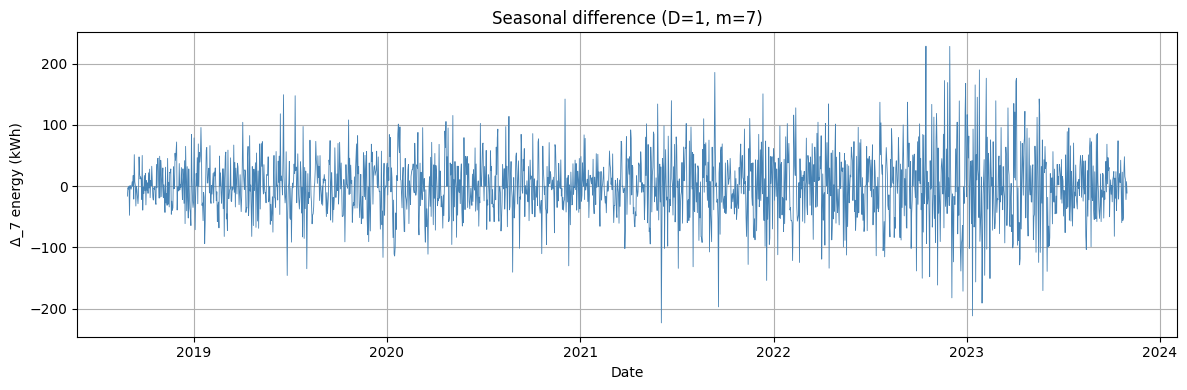

--- ADF test: seasonal difference (D=1, m=7) ---
ADF statistic : -11.3827
p-value       : 0.000000
  critical 1%: -3.4339
  critical 5%: -2.8631
  critical 10%: -2.5676
=> STATIONARY at the 5% level



In [8]:
y_sdiff = y.diff(7).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_sdiff.index, y_sdiff.values, color='steelblue', lw=0.6)
ax.set_title('Seasonal difference (D=1, m=7)')
ax.set_xlabel('Date'); ax.set_ylabel('Δ_7 energy (kWh)')
plt.tight_layout()
plt.show()

_ = adf_report(y_sdiff, label='seasonal difference (D=1, m=7)')

#### ***First + seasonal differencing combined***

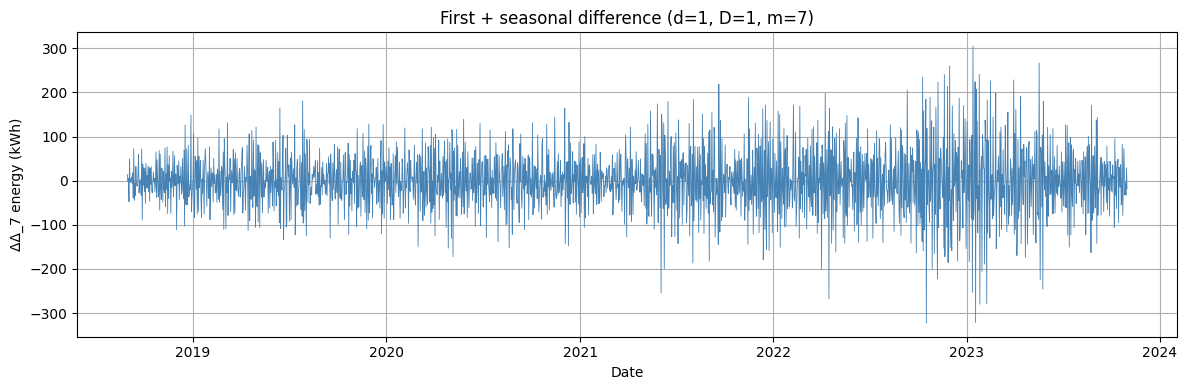

--- ADF test: first + seasonal difference ---
ADF statistic : -14.0593
p-value       : 0.000000
  critical 1%: -3.4339
  critical 5%: -2.8631
  critical 10%: -2.5676
=> STATIONARY at the 5% level



In [9]:
y_both = y.diff().diff(7).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_both.index, y_both.values, color='steelblue', lw=0.6)
ax.set_title('First + seasonal difference (d=1, D=1, m=7)')
ax.set_xlabel('Date'); ax.set_ylabel('ΔΔ_7 energy (kWh)')
plt.tight_layout()
plt.show()

_ = adf_report(y_both, label='first + seasonal difference')

#### ***ACF / PACF on the stationary series***

We used the most aggressively differenced version (`d=1, D=1, m=7`) to read off the candidate AR / MA orders for SARIMA. Lags up to 35 cover five full weekly seasons.

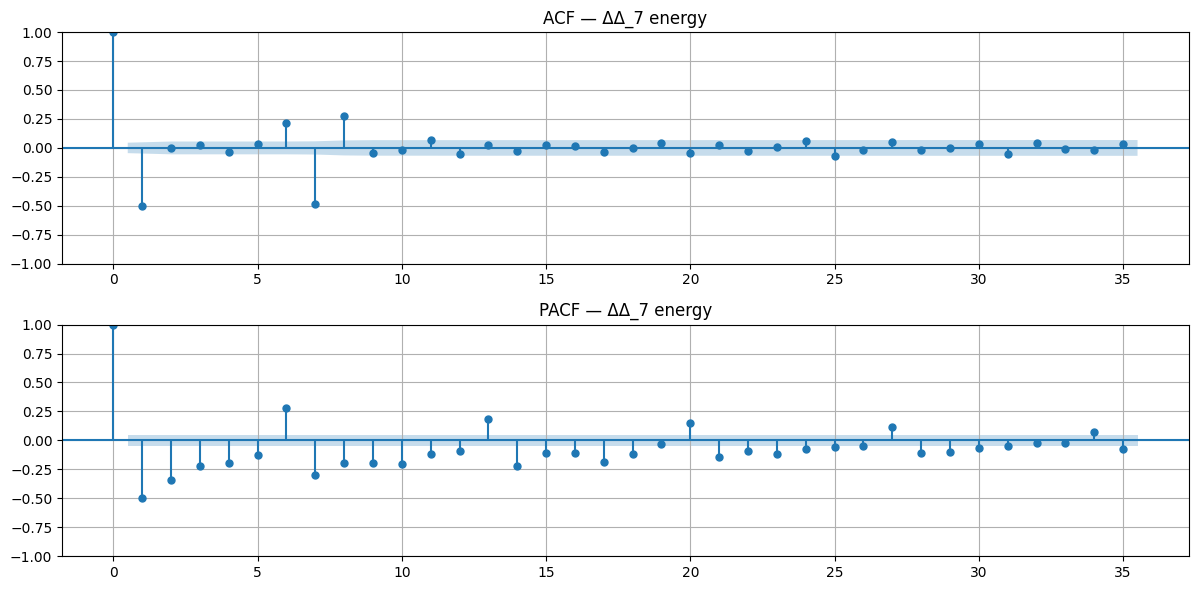

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(y_both,  lags=35, ax=ax1)
plot_pacf(y_both, lags=35, ax=ax2, method='ywm')
ax1.set_title('ACF — ΔΔ_7 energy')
ax2.set_title('PACF — ΔΔ_7 energy')
plt.tight_layout()
plt.show()

#### ***STL decomposition (weekly seasonality)***

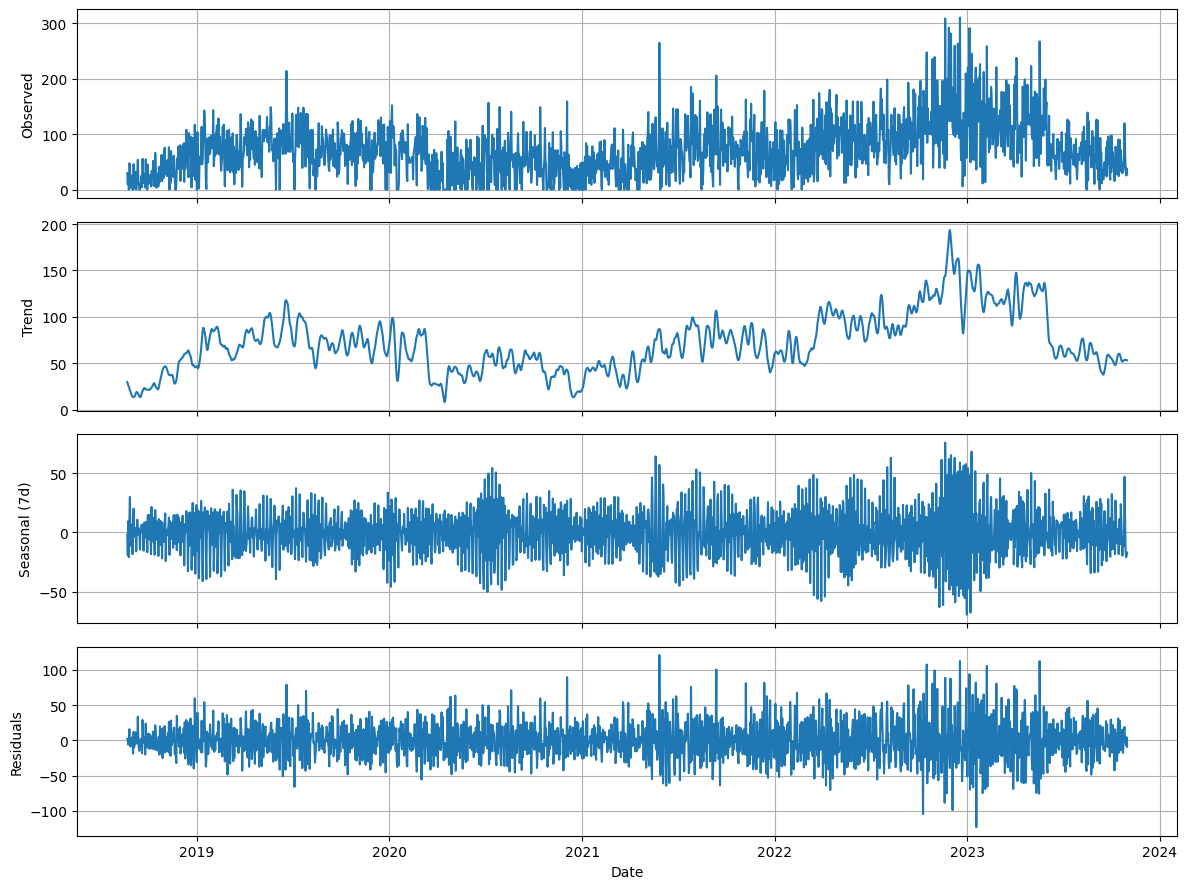

In [11]:
stl = STL(y, period=7).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(12, 9))
ax1.plot(stl.observed); ax1.set_ylabel('Observed')
ax2.plot(stl.trend);    ax2.set_ylabel('Trend')
ax3.plot(stl.seasonal); ax3.set_ylabel('Seasonal (7d)')
ax4.plot(stl.resid);    ax4.set_ylabel('Residuals')
ax4.set_xlabel('Date')
plt.tight_layout()
plt.show()

#### ***Variance check — log transform***

If the rolling standard deviation grew with the level of the series, a log transform would stabilise the variance. We check the rolling-std trend together with the ADF after `log(1 + y)`.

In [12]:
# Pearson correlation between rolling mean and rolling std
mask = roll_mean.notna() & roll_std.notna()
corr = np.corrcoef(roll_mean[mask], roll_std[mask])[0, 1]
print(f'Corr(rolling mean, rolling std) = {corr:.3f}')

y_log = np.log1p(y)
_ = adf_report(y_log.diff().diff(7).dropna(), label='log + first + seasonal diff')

Corr(rolling mean, rolling std) = 0.780
--- ADF test: log + first + seasonal diff ---
ADF statistic : -13.9037
p-value       : 0.000000
  critical 1%: -3.4339
  critical 5%: -2.8631
  critical 10%: -2.5676
=> STATIONARY at the 5% level

